# Network Traffic Prediction (Supervised Learning)

**Monica Joya - ITAI 4370 - Laboratory 03**

## Objective

In this lab I used the provided code to build a model that predicts network traffic levels using historical data.

**Dataset:** Synthetic hourly network traffic data with seasonal patterns.

It applies supervised learning by regression, my first hands-on machine learning model in this course.

Dataset shape: (8570, 9)

First few rows:
             timestamp  hour  day_of_week  is_weekend  is_business_hours  \
84 2023-01-04 12:00:00    12            2       False               True   
85 2023-01-04 13:00:00    13            2       False               True   
86 2023-01-04 14:00:00    14            2       False               True   
87 2023-01-04 15:00:00    15            2       False               True   
88 2023-01-04 16:00:00    16            2       False               True   

    traffic_gbps  traffic_lag_1h  traffic_lag_24h  traffic_rolling_7d  
84     71.050823       77.678321        70.680542           54.166101  
85     67.408125       71.050823        66.971737           54.147588  
86     69.670302       67.408125        57.544738           54.132844  
87     62.594911       69.670302        52.953244           54.090667  
88     55.123982       62.594911        59.818534           54.024632  


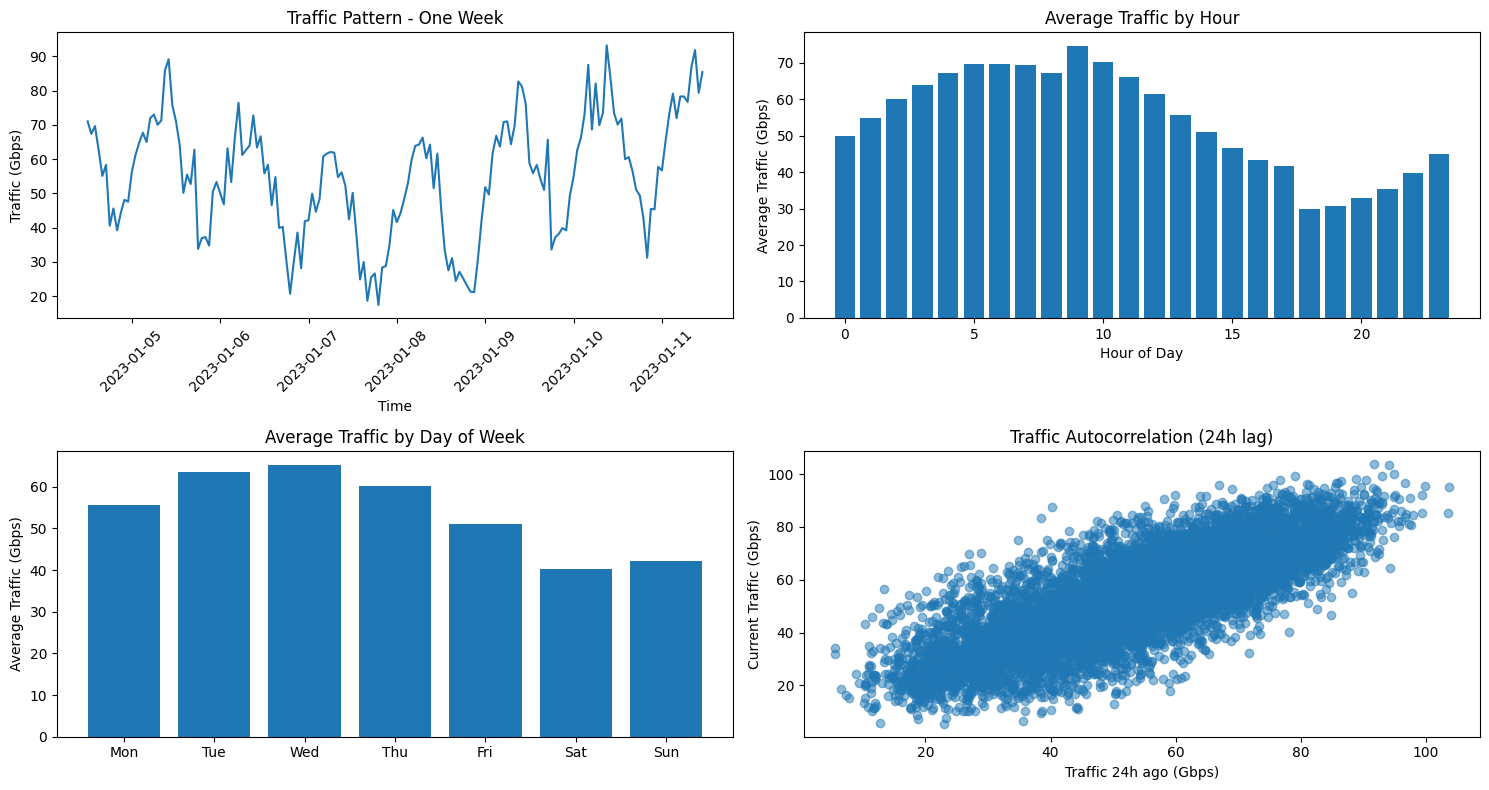


Model Performance:
Training MSE: 17.59
Testing MSE: 34.64
Training R²: 0.946
Testing R²: 0.893

Feature Importance:
              feature  importance
4      traffic_lag_1h    0.815706
0                hour    0.077702
5     traffic_lag_24h    0.035665
1         day_of_week    0.027819
6  traffic_rolling_7d    0.023439
3   is_business_hours    0.017457
2          is_weekend    0.002211


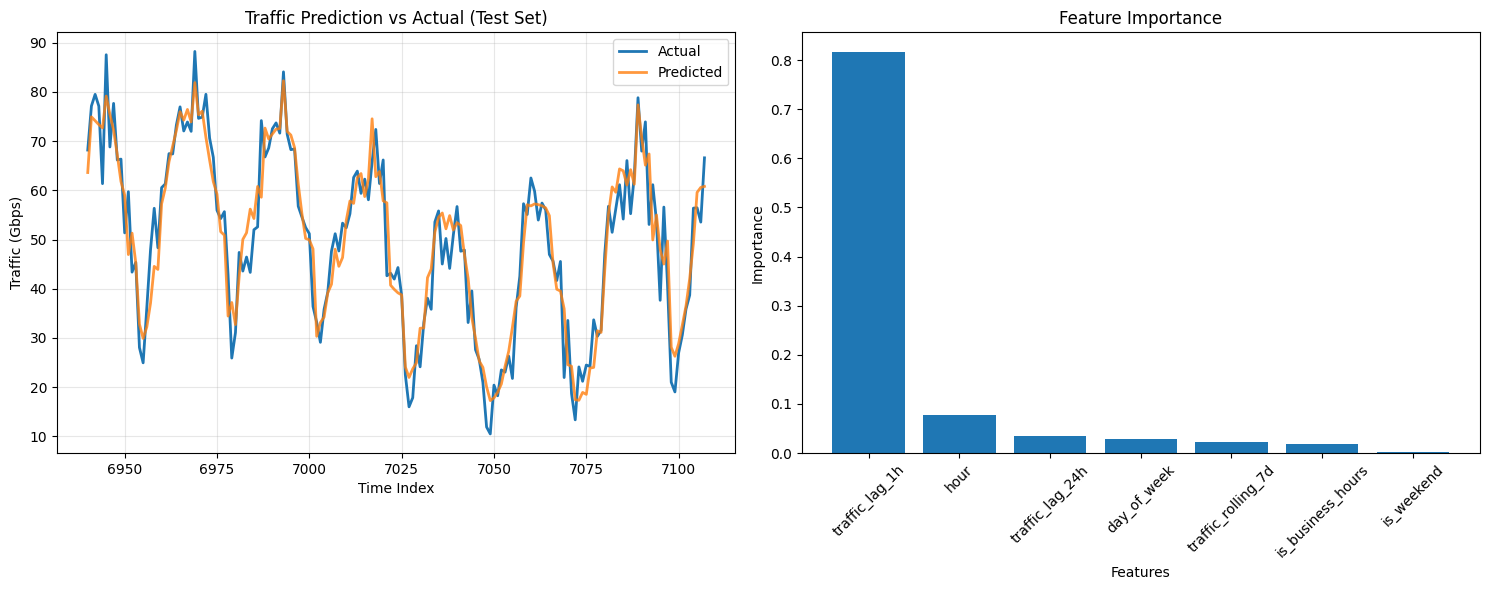

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

# Generate synthetic telecom traffic data
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='h')
n_samples = len(dates)

# Create realistic traffic patterns
hour = dates.hour
day_of_week = dates.dayofweek
day_of_year = dates.dayofyear

# Base traffic with daily and weekly patterns
base_traffic = (
    50 +  # Base level
    20 * np.sin(2 * np.pi * hour / 24) +  # Daily pattern
    10 * np.sin(2 * np.pi * day_of_week / 7) +  # Weekly pattern
    5 * np.sin(2 * np.pi * day_of_year / 365) +  # Annual pattern
    np.random.normal(0, 5, n_samples)  # Noise
)

# Add business hours boost
business_hours = (hour >= 9) & (hour <= 17) & (day_of_week < 5)
base_traffic += business_hours * 15

# Create DataFrame
traffic_data = pd.DataFrame({
    'timestamp': dates,
    'hour': hour,
    'day_of_week': day_of_week,
    'is_weekend': day_of_week >= 5,
    'is_business_hours': business_hours,
    'traffic_gbps': np.maximum(base_traffic, 0)  # Ensure non-negative
})

# Feature engineering
traffic_data['traffic_lag_1h'] = traffic_data['traffic_gbps'].shift(1)
traffic_data['traffic_lag_24h'] = traffic_data['traffic_gbps'].shift(24)
traffic_data['traffic_rolling_7d'] = traffic_data['traffic_gbps'].rolling(
    window=24*7, center=True
).mean()

# Remove rows with NaN values
traffic_data = traffic_data.dropna()

print("Dataset shape:", traffic_data.shape)
print("\nFirst few rows:")
print(traffic_data.head())

# Visualize the data
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.plot(traffic_data['timestamp'][:24*7], traffic_data['traffic_gbps'][:24*7])
plt.title('Traffic Pattern - One Week')
plt.xlabel('Time')
plt.ylabel('Traffic (Gbps)')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
hourly_avg = traffic_data.groupby('hour')['traffic_gbps'].mean()
plt.bar(hourly_avg.index, hourly_avg.values)
plt.title('Average Traffic by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Traffic (Gbps)')

plt.subplot(2, 2, 3)
daily_avg = traffic_data.groupby('day_of_week')['traffic_gbps'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.bar(days, daily_avg.values)
plt.title('Average Traffic by Day of Week')
plt.ylabel('Average Traffic (Gbps)')

plt.subplot(2, 2, 4)
plt.scatter(traffic_data['traffic_lag_24h'], traffic_data['traffic_gbps'], alpha=0.5)
plt.title('Traffic Autocorrelation (24h lag)')
plt.xlabel('Traffic 24h ago (Gbps)')
plt.ylabel('Current Traffic (Gbps)')

plt.tight_layout()
plt.show()

# Prepare features and target
feature_columns = [
    'hour', 'day_of_week', 'is_weekend', 'is_business_hours',
    'traffic_lag_1h', 'traffic_lag_24h', 'traffic_rolling_7d'
]

X = traffic_data[feature_columns]
y = traffic_data['traffic_gbps']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Evaluate the model
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print(f"\nModel Performance:")
print(f"Training MSE: {train_mse:.2f}")
print(f"Testing MSE: {test_mse:.2f}")
print(f"Training R²: {train_r2:.3f}")
print(f"Testing R²: {test_r2:.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nFeature Importance:")
print(feature_importance)

# Plot predictions vs actual
plt.figure(figsize=(15, 6))
test_indices = X_test.index[:168]  # Show one week of test data

plt.subplot(1, 2, 1)
plt.plot(test_indices, y_test.loc[test_indices], label='Actual', linewidth=2)
plt.plot(test_indices, y_pred_test[:len(test_indices)], 
         label='Predicted', linewidth=2, alpha=0.8)
plt.title('Traffic Prediction vs Actual (Test Set)')
plt.xlabel('Time Index')
plt.ylabel('Traffic (Gbps)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

** My Observations **

The model performed well on this dataset. The testing R squared was 0.893, meaning it explained about 89 percent of the variation in traffic on data it had not seen. The training R squared was higher at 0.946, and the training MSE (17.59) was lower than the testing MSE (34.64). That gap is normal and shows mild overfitting, where the model fits the training data a little better than new data.

Feature importance was dominated by traffic_lag_1h at about 0.82, so the strongest predictor of traffic in any hour is the traffic from the hour before. Hour of day was a distant second at about 0.08. The remaining features, including the 24 hour lag, day of week, and the 7 day rolling average, each contributed only a small amount.

The exploratory plots match this. Average traffic by hour peaks around mid morning and dips overnight, average traffic by day of week is higher on weekdays than weekends, and the 24 hour autocorrelation scatter trends upward, which confirms that traffic is similar from one day to the next. In the prediction plot, the predicted line tracks the actual line closely across the test week, which is the visual version of that 0.893 R squared.